In [1]:
import numpy as np
from sklearn.datasets import load_diabetes

In [4]:
data = load_diabetes()
xData = data['data']
yData = data['target']

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
xTrain, xTest, yTrain, yTest = train_test_split(xData, yData, random_state=42)

In [9]:
from sklearn.preprocessing import MinMaxScaler

In [10]:
x_scaler = MinMaxScaler()
xTrain = x_scaler.fit_transform(xTrain)
xTest = x_scaler.transform(xTest)

In [12]:
yTrain.shape

(331,)

In [18]:
y_scaler = MinMaxScaler()
yTrain = y_scaler.fit_transform(np.expand_dims(yTrain, axis=-1))
yTest = y_scaler.transform(np.expand_dims(yTest, axis=-1))

In [92]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

def linear(x):
    return x

def d_sigmoid(sigmoid_x):
    return sigmoid_x * (1+sigmoid_x)

In [115]:
n0 = xTrain.shape[1] # = 10
m = 8
k = 4
t = 1

a = -1
b = 1

# weight initialization
w1 = np.random.uniform(a, b, (m, n0))
w2 = np.random.uniform(a, b, (k, m))
w3 = np.random.uniform(a, b, (t, k))

eta = 0.01
max_epochs = 100

In [116]:
loss_list = []
loss_list_test = []
for epoch in range(max_epochs+1):
    
    #input layer
    net1 = np.dot(xTrain, w1.T)
    o1 = sigmoid(net1)
    
    # hidden layer 1:
    net2 = np.dot(o1, w2.T)
    o2 = sigmoid(net2)
    
    # output layer:
    net3 = np.dot(o2, w3.T)
    output = linear(net3)
    
    # calculate Error & Loss (Cost Function)
    error = yTrain - output
    loss = np.square(error).mean()
    loss_list.append(loss)
    
    # Back Propagation:
    
    delta_3 = 1 * error
    delta_2 = np.dot(delta_3, w3) * d_sigmoid(o2)
    delta_1 = np.dot(delta_2, w2) * d_sigmoid(o1)
    
    
    w3 = w3 + eta * np.dot(delta_3.T, o2) / len(xTrain)
    w2 = w2 + eta * np.dot(delta_2.T, o1) / len(xTrain)
    w1 = w1 + eta * np.dot(delta_1.T, xTrain) / len(xTrain)
    
    if epoch%10 == 0:
        print(f"Epoch {epoch} - loss: {loss_list[epoch]}")
    
    # test:
    #input layer
    net1 = np.dot(xTest, w1.T)
    o1 = sigmoid(net1)
    
    # hidden layer 1:
    net2 = np.dot(o1, w2.T)
    o2 = sigmoid(net2)
    
    # output layer:
    net3 = np.dot(o2, w3.T)
    output_test = linear(net3)
    
    # calculate Error & Loss (Cost Function)
    error_test = yTest - output_test
    loss_test = np.square(error_test).mean()
    loss_list_test.append(loss_test)

Epoch 0 - loss: 2.6980078839899297
Epoch 10 - loss: 1.7793404453242494
Epoch 20 - loss: 1.2679828381278735
Epoch 30 - loss: 0.9461218153998934
Epoch 40 - loss: 0.7275454091849486
Epoch 50 - loss: 0.5715234111997071
Epoch 60 - loss: 0.45630598483625123
Epoch 70 - loss: 0.36919212017350866
Epoch 80 - loss: 0.30223673592206385
Epoch 90 - loss: 0.250189203856715
Epoch 100 - loss: 0.20942082346835317


In [117]:
import matplotlib.pyplot as plt

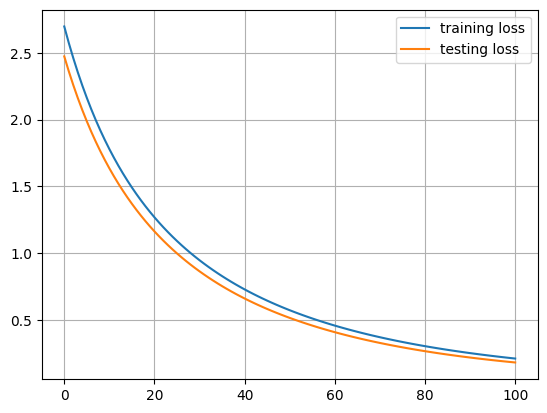

In [118]:
plt.plot(loss_list, label="training loss")
plt.plot(loss_list_test, label="testing loss")
plt.legend()
plt.grid()